# telos vs STLCG++

Time and memory benchmarks between `telos` and [STLCG++](https://github.com/UW-CTRL/stlcg-plus-plus), across pairwise identical evaluation schemas.

All measurements: `bench.py`; cached rows: `results/`.

In [13]:
import torch
from bench import parity, grid, sweep, speedups, plot, cached

print((gpu := torch.cuda.get_device_properties(0)).name, f'{round(gpu.total_memory / 1e9, 1)}GB')
print(torch.__version__)

NVIDIA GeForce RTX 3080 Laptop GPU 16.8GB
2.8.0+cu126


## Parity

Among the algebras provided by `telos`, three map directly to the three STLCG++ "approximation methods".
This section empirically asserts equal evaluations between the two frameworks (up to finite precision arithmetic).
The check draws 20 random formulas at each nesting depth of 2, 4, and 6, over all connectives;
both tools evaluate each formula on a fresh random trace of 37 time steps. The check reports
the maximum absolute difference between the two output trajectories.

The pairings are
* `Robustness` to `approx_method='true'` (`exact`),
* `LSE(p=β)` to `'logsumexp'` (`lse`), and
* `Boltzmann(beta=β)` to `'softmax'` (`softmax`),
with `temperature=β` throughout.


One transformation is applied on the STLCG++ side: STLCG++ evaluates nested `∧`/`∨` chains as a
single n-ary reduction (`separate_and`/`separate_or`) rather than as the written binary tree, and
under the non-associative softmax the two disagree. To circumvent the discrepancy, `translate` wraps
chained subformulas in double negations, which are semantically inert but block the flattening, so both
tools evaluate the same tree.

In [14]:
rows = parity()
print(f"{len(rows)} formulas")
for key in ('exact', 'lse', 'softmax'):
    worst = max(rows, key=lambda r: r[key])
    print(f"worst {key:8s} {worst[key]:.1e}  ({worst['formula']})")

60 formulas
worst exact    0.0e+00  ((p ∨ p) → q)
worst lse      9.5e-07  (¬ ((⊤) 𝒰 (¬ (¬ ((⊤) 𝒰 (¬ (¬ ((⊤) 𝒰 (¬ (p ∧ p))))))))))
worst softmax  7.2e-07  (¬ ((⊤) 𝒰 (¬ (p ∧ q))))


## Timing grid

This section spot-checks relative speed across the trace length × batch size plane.
Four formulas are timed at trace lengths 64 through 4096 and batch sizes 1 through 64,
under the exact and logsumexp methods, forward and forward+backward.
Reported is the geometric mean (min, max) of the per-cell speedup of telos over STLCG++;
`oom` lists the (trace length, batch size) cells where STLCG++ runs out of memory on unbounded `U`.

In [16]:
s = speedups(cached('grid', lambda: grid()))
print('speedup of telos over STLCG++, geometric mean (min, max):')
for (kind, pass_), (gm, lo, hi) in ((k, v) for k, v in s.items() if isinstance(k, tuple)):
    print(f'  {kind:4s} {pass_:8s} {gm:6.1f}  ({lo:.1f}, {hi:.1f})')
print(f"{s['cells']} cells; STLCG++ out of memory at (T, B): "
      + ', '.join(map(str, s['oom'])))

speedup of telos over STLCG++, geometric mean (min, max):
  ◇/□  fwd         8.7  (2.5, 104.5)
  ◇/□  fwd+bwd     3.6  (1.3, 33.1)
  U    fwd        85.6  (44.1, 268.1)
  U    fwd+bwd    47.0  (20.1, 140.4)
112 cells; STLCG++ out of memory at (T, B): (256, 64), (1024, 1), (1024, 16), (4096, 1)


## Scaling

This section compares evaluation cost between the two frameworks. The sweep times a forward+backward
pass at batch size 1 over trace lengths 64 through 4096, one figure per approximation method.
Lines end where an implementation stops being measurable: a red x marks an out-of-memory point
(placed by extrapolating the line's established slope); CUTOFF marks a steady-state runtime
past 10 minutes.

The lines are, with hue the tool and the darker shade its fast path:

* `telos (algebra-native)`: closed-form sequence reductions (cumulative scans for `◇`/`□`, a prefix-sharing
  span for unbounded `U`); the algebra is `Robustness`, `LSE`, `Boltzmann` per method, respectively.
* `telos (algebra-agnostic fallback)`: the same reductions derived generically from the algebra's
  primitives via `scan`/`fold`; the path taken by algebras without closed forms. Exact only: a `scan`/`fold`
  of the non-associative softmax meet computes a different semantics.
* `STLCG++ (masked)`: the default; time-parallel over masked signal copies.
* `STLCG++ (recurrent)`: the original STLCG formulation; a step-by-step scan over time.
  Linear memory forward, but under backward the retained autograd graph grows with the
  rollout, so it too runs out of memory on unbounded `U`.

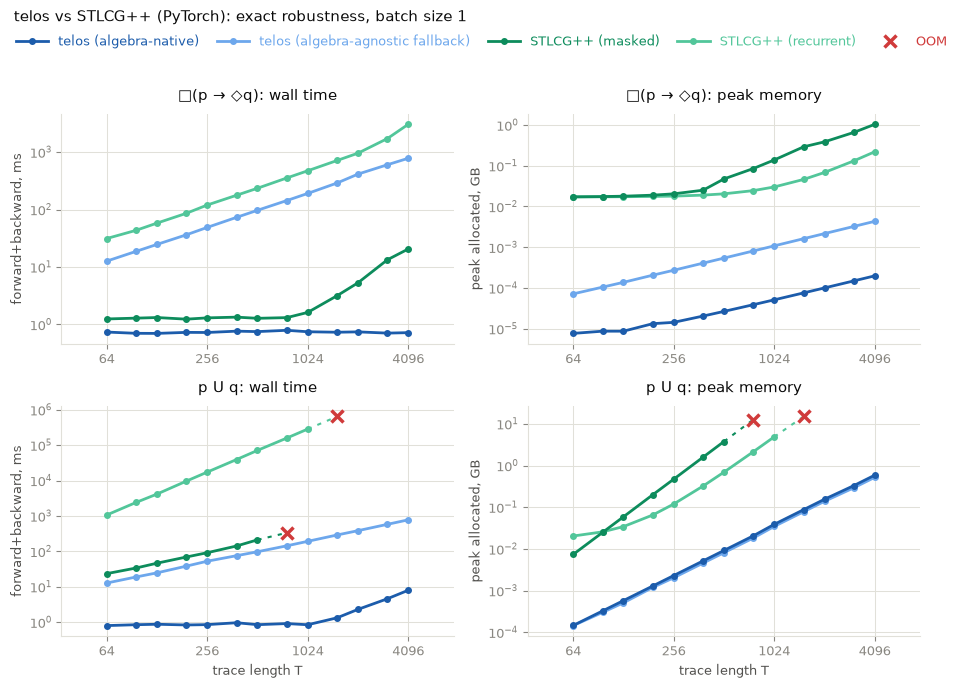

In [17]:
fig = plot(cached('sweep', lambda: sweep()),
           'telos vs STLCG++ (PyTorch): exact robustness, batch size 1',
           total_gb=gpu.total_memory / 1e9)
fig.savefig('scaling.png', dpi=200, bbox_inches='tight')

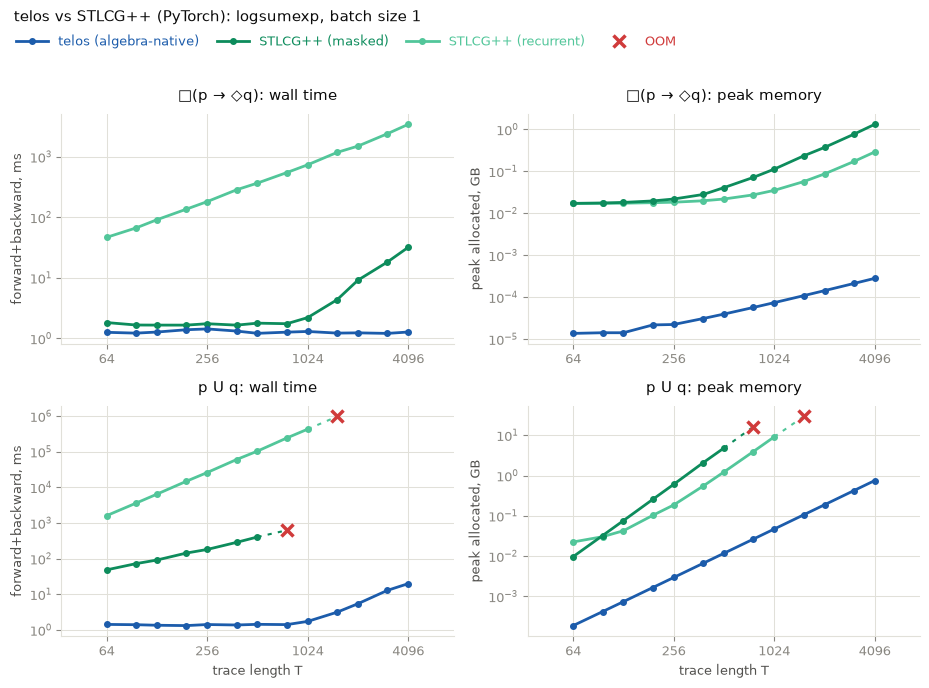

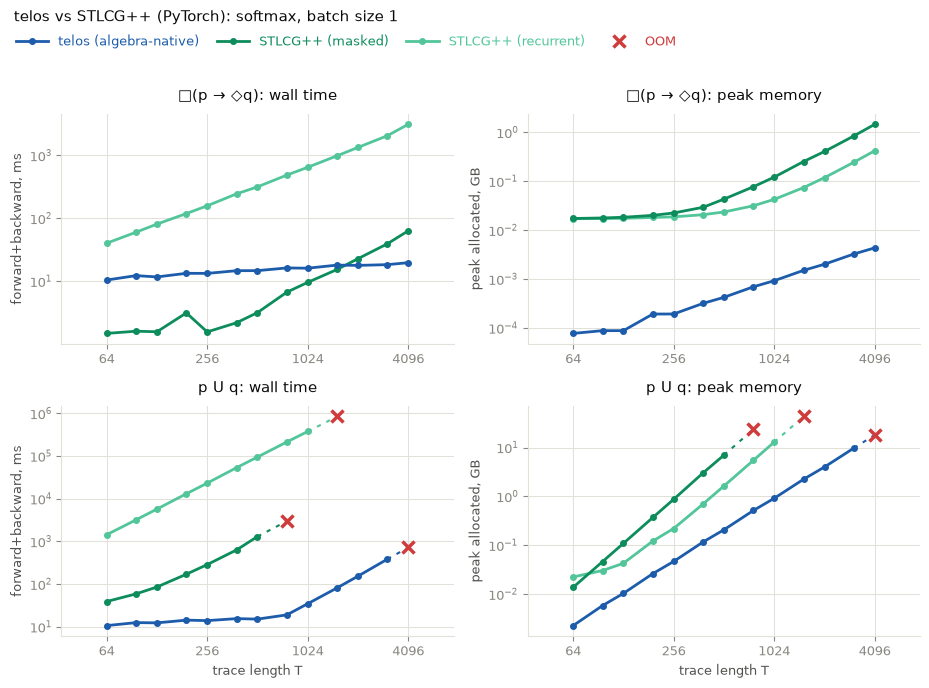

In [18]:
for method, name in (('lse', 'logsumexp'), ('softmax', 'softmax')):
    impls = tuple(f'{backend}-{method}' for backend in ('telos', 'masked', 'recurrent'))
    fig = plot(cached(f'sweep_{method}', lambda impls=impls: sweep(impls=impls)),
               f'telos vs STLCG++ (PyTorch): {name}, batch size 1',
               total_gb=gpu.total_memory / 1e9)
    fig.savefig(f'scaling_{method}.png', dpi=200, bbox_inches='tight')

telos derives temporal operators from per-algebra sequence reductions: closed forms where
they exist (`◇`/`□` are O(T) scans, unbounded `U` an O(T²) span), a generic scan/fold
derivation otherwise. The masking construction is O(T²) and O(T³) respectively.